In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.svm import SVC         # polynomial model
from sklearn.svm import LinearSVC   # linear model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [3]:
url = 'winequality-white.csv'
df = pd.read_csv(url, sep=";", engine='pyarrow')

In [4]:
df['quality'] >=6

0        True
1        True
2        True
3        True
4        True
        ...  
4893     True
4894    False
4895     True
4896     True
4897     True
Name: quality, Length: 4898, dtype: bool

In [5]:
# 1.3 Convert the target variable into a binary classification problem
df['quality'] = (df['quality'] >=6).astype(int)
df['quality'].dtype
#df['quality'].value_counts()

dtype('int64')

In [6]:
df.size

58776

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.size

47532

In [9]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
df.shape

(3961, 12)

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(3961, 12)

In [13]:
column_list = df.columns
column_list

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [14]:
df.isnull().sum()
# 1.2 Handle any missing values (if present) 
# none present

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [15]:
dfz = pd.DataFrame(df, columns=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'])
dfz

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


In [16]:
# 2. Train-Test Split START

X = dfz.drop('quality', axis=1) # training set
y = dfz['quality'] # target

In [17]:
# 2. Train-Test Split END
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

In [18]:
scalar = StandardScaler()

In [19]:
dfz.shape

(3961, 12)

In [20]:
dfz['quality'].value_counts()

quality
1    2613
0    1348
Name: count, dtype: int64

In [21]:
# kNN determining the optimal k value

In [22]:
# Method adapted from: https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/
# Purpose: for loop for finding the optimal k value
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1,31)} # why we write it like this?

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1') # what is the meaning of scoring?
grid_search.fit(X_train, y_train)

optimal_k = grid_search.best_params_['n_neighbors']
print(f'The optimal K value is: {optimal_k}')
best_knn = grid_search.best_estimator_
print(f'OR: The optimal K value is: {best_knn}')

if optimal_k < 3:
    print(f'It is likely that at optimal k value of {optimal_k}, the kNN model may be underfitted')

The optimal K value is: 29
OR: The optimal K value is: KNeighborsClassifier(n_neighbors=29)


The optimal K value is: 28


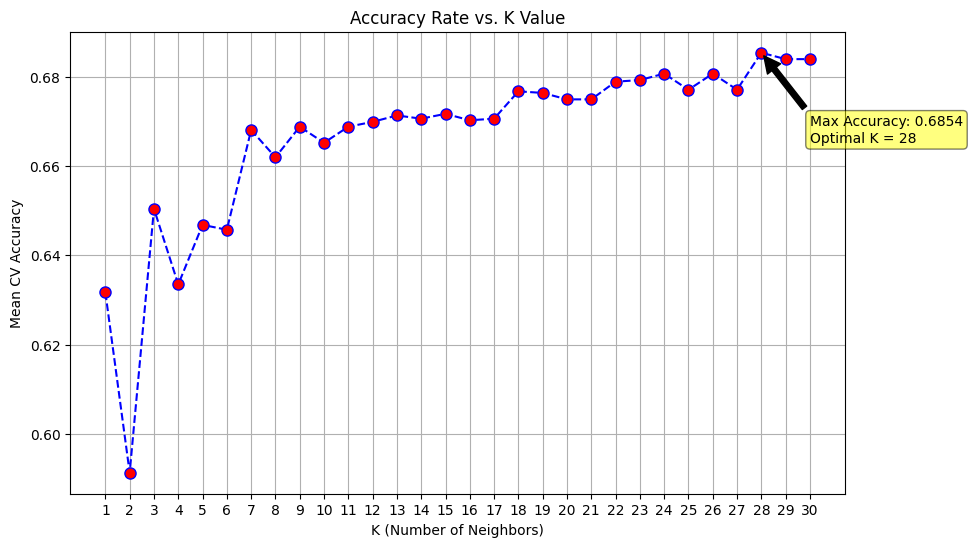

In [23]:
# AI GENERATED CODE: gemini.google.com
# TEMPORARY

# 2. Setup KNN and Parameter Grid
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1, 31)} 

# 3. Run Grid Search (Cross-Validation = 5)
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 4. Extract Results
optimal_k = grid_search.best_params_['n_neighbors']
mean_scores = grid_search.cv_results_['mean_test_score']
k_values = range(1, 31)

# 5. Print Results
print(f'The optimal K value is: {optimal_k}')

if optimal_k < 3:
    print(f'Note: At k={optimal_k}, the model may be overfitted (too sensitive to noise).')

# 6. Create the Graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_scores, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

# Add annotation for the Max Value
plt.annotate(f'Max Accuracy: {grid_search.best_score_:.4f}\nOptimal K = {optimal_k}', 
             xy=(optimal_k, grid_search.best_score_), 
             xytext=(optimal_k + 2, grid_search.best_score_ - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [24]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultskNN = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultskNN[name] = accuracy_score(y_test, y_pred)

resultskNN

{'kNN': 0.6846089150546678}

In [25]:
# SVM: Experimentation with different kernel functions (linear, polynomial, RBF) 
# and select the best kernel using cross-validation.

In [26]:
# Code referenced: https://scikit-learn.org/stable/modules/svm.html
# Purpose: for identifying different SVM models

models = {
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
}

resultsSVC = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsSVC[name] = accuracy_score(y_test, y_pred)

resultsSVC

{'LinearSVC': 0.7468460891505467,
 'RBF SVC': 0.6677880571909167,
 'Polynomial SVC': 0.6593776282590412}

In [27]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsLDA = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsLDA[name] = accuracy_score(y_test, y_pred)

resultsLDA

{'kNN': 0.6846089150546678}

In [28]:
# Evaluation of models

In [29]:
modelsAll = {
    "LDA": LinearDiscriminantAnalysis(),
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsAll = {}

for name, model in modelsAll.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsAll[name] = accuracy_score(y_test, y_pred)

    print(f'This is model: {model} with name: {name}')
    print(classification_report(y_test, y_pred))
    print('')
    print('Here is a confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('----------------------------------')

resultsAll

This is model: LinearDiscriminantAnalysis() with name: LDA
              precision    recall  f1-score   support

           0       0.68      0.50      0.58       405
           1       0.77      0.88      0.82       784

    accuracy                           0.75      1189
   macro avg       0.73      0.69      0.70      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[202 203]
 [ 94 690]]
----------------------------------
This is model: SVC(kernel='linear') with name: LinearSVC
              precision    recall  f1-score   support

           0       0.67      0.50      0.58       405
           1       0.77      0.87      0.82       784

    accuracy                           0.75      1189
   macro avg       0.72      0.69      0.70      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[204 201]
 [100 684]]
----------------------------------
This is model: SVC(gamma=0.7) with name: RBF SVC
       

{'LDA': 0.7502102607232969,
 'LinearSVC': 0.7468460891505467,
 'RBF SVC': 0.6677880571909167,
 'Polynomial SVC': 0.6593776282590412,
 'kNN': 0.6846089150546678}

In [30]:
# 5.1 Performance Comparison
# Compare Accuracy, Precision, Recall, and F1-Score across k-NN, SVM, and LDA.
# Identify which model achieved the highest overall scores.

# 5.2 Model Strengths
# k-NN: Discuss its simplicity and effectiveness with local patterns.
# SVM: Discuss its power in high-dimensional spaces and kernel flexibility.
# LDA: Discuss its efficiency and performance if classes are linearly separable.

# 5.3 Model Weaknesses
# k-NN: Note sensitivity to noise/outliers and computational cost on large data.
# SVM: Note the "black box" nature and intensive tuning for C and Gamma.
# LDA: Note the reliance on normality assumptions and equal covariance.

# 5.4 Conclusion for Wine Dataset
# Which model is best for predicting wine quality based on these specific chemical features?
# Mention if any model struggled with class imbalance (Good vs. Poor quality).

In [31]:
# 5.1 Performance comparison
# Accuracy, Precision, Recall, and F1-Score

In [48]:
# AI generated code gemini.google.com
# Purpose: Used to quickly compare results

import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

comparison_data = []

for name, model in modelsAll.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    
    comparison_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

df_compare = pd.DataFrame(comparison_data).set_index("Model")

print("--- Model Performance Comparison ---")
print(df_compare.round(4)) 

--- Model Performance Comparison ---
                Accuracy  Precision  Recall  F1-Score
Model                                                
LDA               0.7502     0.7276  0.6894    0.6996
LinearSVC         0.7468     0.7220  0.6881    0.6976
RBF SVC           0.6678     0.7082  0.5153    0.4342
Polynomial SVC    0.6594     0.5844  0.5197    0.4639
kNN               0.6846     0.6399  0.6170    0.6213


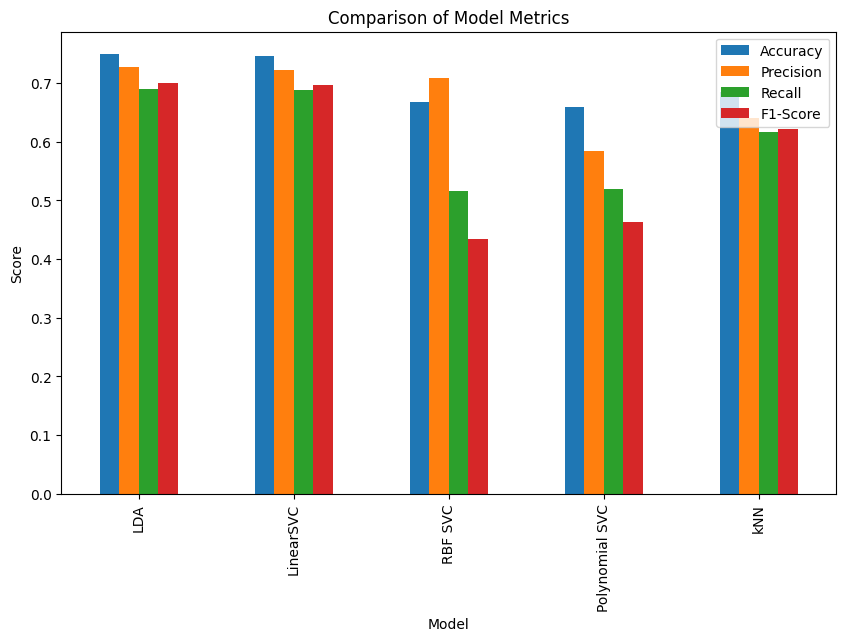

In [49]:
# AI generated code gemini.google.com
# Purpose: Used to quickly compare results

import matplotlib.pyplot as plt
df_compare.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Model Metrics")
plt.ylabel("Score")
plt.show()

In [50]:
# For accuracy, LDA and LinearSVC compare quite closely at 0.7502 and 0.7468 respectively
# For precision, LDA and LinearSVC again compare quite closely at 0.7276 and 0.7220 respectively
# For recall, LDA and LinearSVC again compare quite closely at 0.6881 and 0.6894 respectively
# For F1-Score, LDA and LinearSVC again compare quite closely at 0.6996 and 0.6976 respectively with kNN following closely at 0.6213

# This means generally, in terms of the the performance of the clasification models
# LDA performs the best, with LinearSVC as a close second

In [45]:
df_compare.describe()

,Accuracy,Precision,Recall,F1-Score
count,5.000000,5.000000,5.000000,5.000000
mean,0.701766,0.676402,0.605909,0.583311
std,0.043660,0.062256,0.085861,0.127016
min,0.659378,0.584372,0.515330,0.434168
25%,0.667788,0.639926,0.519695,0.463876
50%,0.684609,0.708191,0.617010,0.621346
75%,0.746846,0.721967,0.688076,0.697555
max,0.750210,0.727554,0.689434,0.699609


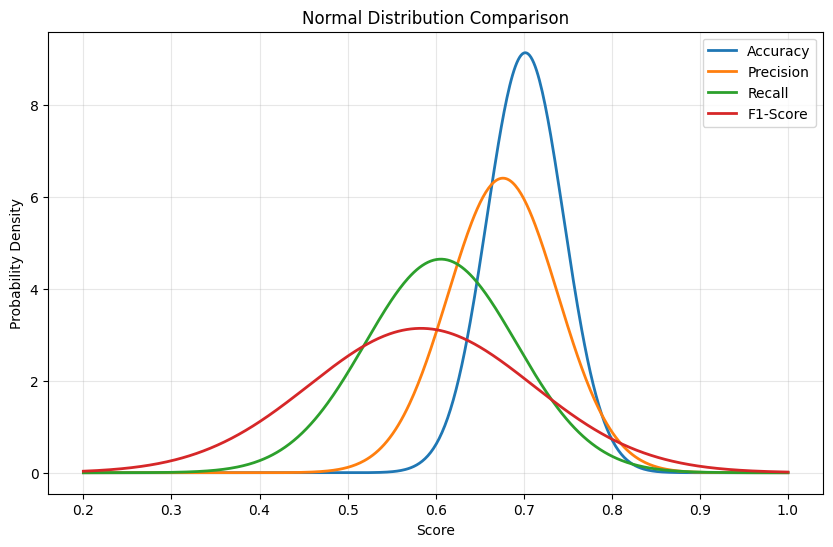

In [ ]:
# AI generated code gemini.google.com
# Used for a quick data comparison

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

metrics = {
    'Accuracy':  {'mu': 0.701766, 'std': 0.043660},
    'Precision': {'mu': 0.676402, 'std': 0.062256},
    'Recall':    {'mu': 0.605909, 'std': 0.085861},
    'F1-Score':  {'mu': 0.583311, 'std': 0.127016}
}

x = np.linspace(0.2, 1.0, 500)
plt.figure(figsize=(10, 6))

for name, val in metrics.items():
    plt.plot(x, stats.norm.pdf(x, val['mu'], val['std']), label=name, lw=2)

plt.title('Normal Distribution Comparison')
plt.xlabel('Score')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Further analysis
# Here, Probability Density represents the likelihood of your model achieving a specific score
# And socre, being the score that was achieved by the models


# Accuracy: the percentage of total guesses that were correct.
# Accuracy results: we can see that all of the models generally faired quite well and concentrated at a similar mean value
# Extrapolation: regardless of the innequal spread of data, 65.9% being clasified as good wine and 34.0% as bad in the original data, overall, the performance is high which could suggest the model is reliable, but accuracy alone may be hiding specific failures in the minority class (Bad Wine).
# 
# Precision: of everything the model claimed was positive, how many were actually correct?
# Precision results: whilst most models comapred similarly to each other, the Polynomial SVC and kNN models faired quite poorly on this metric
# Extrapolation: the Polynomial SVC and kNN models suffered with actually.... 
# 
# Recall:
# Recall results:
# Extrapolation:
# 
# F1-Score: 
# F1-Score results:
# Extrapolation: 

In [63]:
# Supporting data
dfz['quality'].value_counts(normalize=True) * 100 # percentage distribution

quality
1    65.96819
0    34.03181
Name: proportion, dtype: float64